# Water Segmentation Using Optical and Multispectral Satellite Data

This notebook demonstrates how to **segment water bodies** from satellite imagery using **multispectral and optical data**. 

Accurate water segmentation is important for:
- Flood monitoring and management  
- Environmental conservation  
- Water resource planning  

I used a Harmonized Sentinel-2/Landsat dataset where each sample includes:

- 12 channels (spectral bands + geospatial layers)
    - Coastal aerosol
    - Blue
    - Green
    - Red
    - NIR
    - SWIR1
    - SWIR2
    - QA BAND
    - Merit DEM
    - Copernicus DEM
    - ESA world cover map
    - Water occurrence probebility
- A binary mask indicating ,water (1) / non-water (0)

Ground sampling distance = 30 m
Patch size = 512 pixels



In [3]:
import numpy as np
import rasterio
from PIL import Image
import cv2
from tqdm import tqdm
import os
from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms.functional as TF
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader,TensorDataset
import matplotlib.pyplot as plt



In [4]:
image_path = r"C:\Users\walaa\Desktop\Cellula CV\Water Segmentation\From Scratch\data\images"
label_path = r"C:\Users\walaa\Desktop\Cellula CV\Water Segmentation\From Scratch\data\labels"

print("Number of images:", len(os.listdir(image_path)))
print("Number of labels:", len(os.listdir(label_path)))



Number of images: 306
Number of labels: 456


In [5]:
image_files = sorted(os.listdir(image_path))
label_files = sorted(os.listdir(label_path))

print("First 10 image files:", image_files[:10])
print("First 10 label files:", label_files[:10])


First 10 image files: ['0.tif', '1.tif', '10.tif', '100.tif', '101.tif', '102.tif', '103.tif', '104.tif', '105.tif', '106.tif']
First 10 label files: ['0.png', '1.png', '10.png', '100.png', '100_184.png', '101.png', '101_89.png', '102.png', '102_179.png', '103.png']


In [6]:
image_ids = set([f.replace(".tif", "") for f in image_files])
label_ids = set([f.replace(".png", "") for f in label_files])

# Keep only labels without suffix
clean_label_ids = set([lid for lid in label_ids if "_" not in lid])

print("Matching IDs count:", len(image_ids.intersection(clean_label_ids)))


Matching IDs count: 306


In [7]:
label_sample = np.array(Image.open(os.path.join(label_path, "0.png")))
print(np.unique(label_sample))


[0 1]


In [8]:
image_file = "0.tif"
image_path = os.path.join(image_path, image_file)

with rasterio.open(image_path) as src:
    image = src.read()

print("Shape:", image.shape)


Shape: (12, 128, 128)


c:\Users\walaa\AppData\Local\Programs\Python\Python314\Lib\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Preprocessing:

In [9]:
image_dir = r"C:\Users\walaa\Desktop\Cellula CV\Water Segmentation\From Scratch\data\images"
label_dir = r"C:\Users\walaa\Desktop\Cellula CV\Water Segmentation\From Scratch\data\labels"

images_list = []
masks_list = []


for img_file in tqdm(image_files):

    image_id = img_file.replace(".tif", "")
    if image_id not in clean_label_ids:
        continue

    image_path = os.path.join(image_dir, img_file)

    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    #resize each band
    resized_image = []
    for band in image:
        resized_band = cv2.resize(band,(128, 128),interpolation=cv2.INTER_LINEAR)
        resized_image.append(resized_band)

    image = np.stack(resized_image)
    images_list.append(image)

    mask_path = os.path.join(label_dir, image_id + ".png")
    mask = np.array(Image.open(mask_path)).astype(np.float32)

    #resize mask using NEAREST
    mask = cv2.resize(mask,(128, 128),interpolation=cv2.INTER_NEAREST)
    masks_list.append(mask)

X = np.array(images_list)
y = np.array(masks_list)

print("Final image tensor shape:", X.shape)
print("Final mask tensor shape:", y.shape)

100%|██████████| 306/306 [00:08<00:00, 36.45it/s]


Final image tensor shape: (306, 12, 128, 128)
Final mask tensor shape: (306, 128, 128)


Normalisation:

In [10]:
means = X.mean(axis=(0, 2, 3)) #(N, *C*, H, W)
stds = X.std(axis=(0, 2, 3))

for i in range(X.shape[1]):
    X[:, i, :, :] = (X[:, i, :, :] - means[i]) / (stds[i] + 1e-8)

print("Normalization complete.")
print("Means:", means)
print("Stds:", stds)

Normalization complete.
Means: [ 396.4676    494.62097   822.32007   973.67523  2090.1118   1964.051
 1351.2747    102.739655  141.80382   300.7412     35.102535    9.753329]
Stds: [ 270.06662   325.97922   418.12158   586.70294  1055.9846   1191.4221
  961.76245    48.804028 1364.981     496.03876    20.184526   27.758299]


In [11]:
print("Means:", means)
print("Stds:", stds)

Means: [ 396.4676    494.62097   822.32007   973.67523  2090.1118   1964.051
 1351.2747    102.739655  141.80382   300.7412     35.102535    9.753329]
Stds: [ 270.06662   325.97922   418.12158   586.70294  1055.9846   1191.4221
  961.76245    48.804028 1364.981     496.03876    20.184526   27.758299]


In [12]:
print("New means per band:", X.mean(axis=(0, 2, 3)))
print("New stds per band:", X.std(axis=(0, 2, 3)))

New means per band: [ 3.1243741e-07  1.6751632e-07 -6.6850697e-07 -4.4625568e-07
 -7.7563953e-07 -3.6941245e-07 -7.3921444e-07 -4.3783118e-07
  7.5674528e-08  3.1165828e-07 -8.9991325e-08 -7.1486618e-08]
New stds per band: [0.9999997  0.9999998  0.99999994 1.0000001  0.9999997  0.9999998
 1.0000002  0.99999964 1.0000001  1.0000001  0.99999976 0.9999998 ]


In [13]:
total_images = X.shape[0]
print(f"Total images: {total_images}")

Total images: 306


## Visualisation:

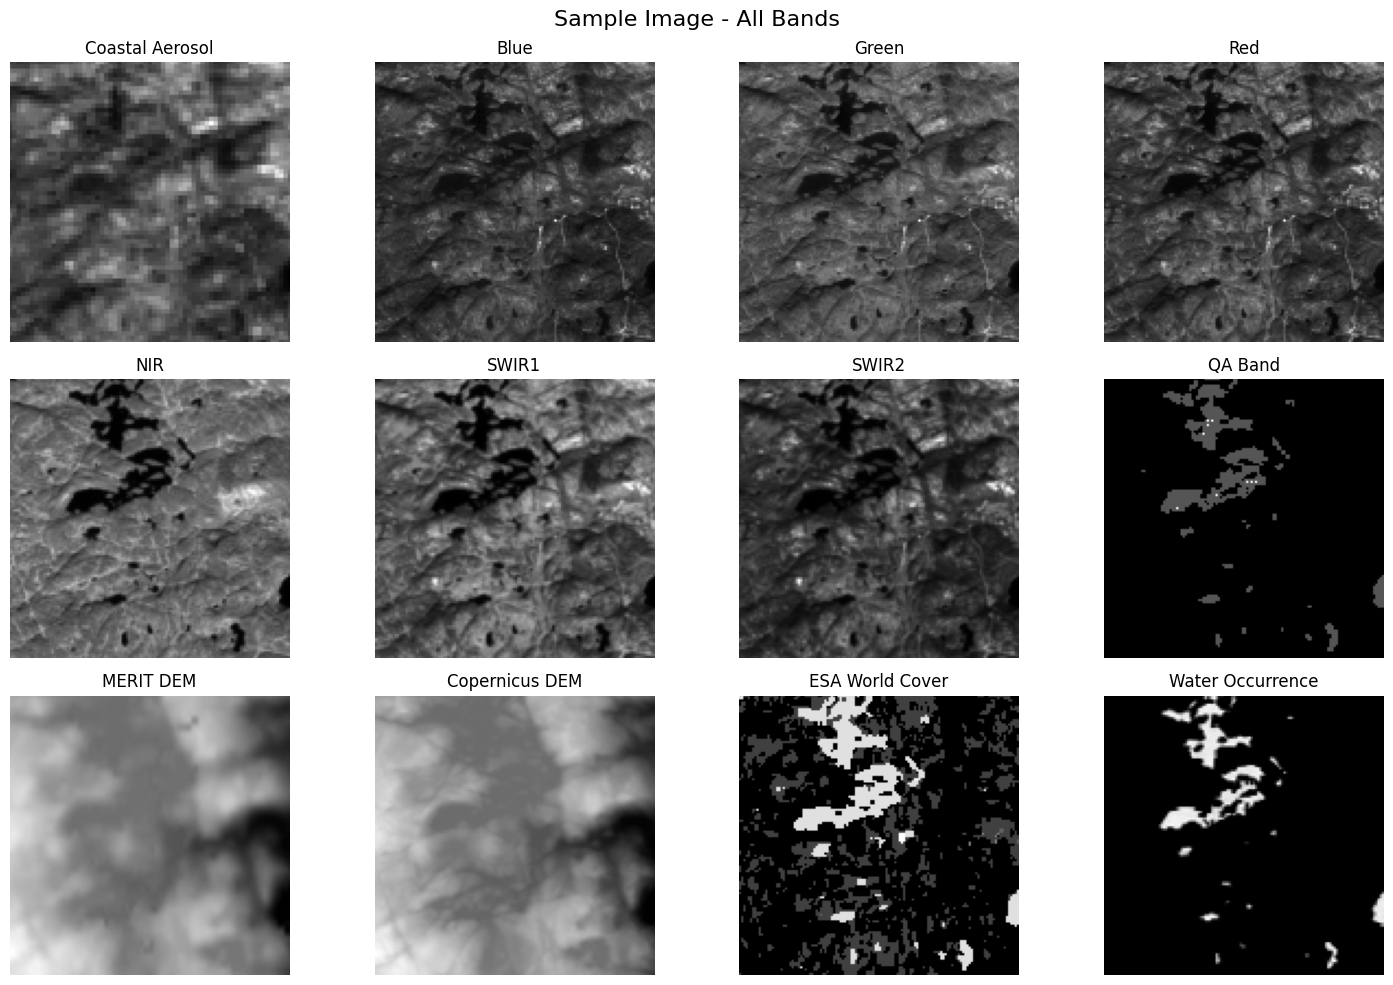

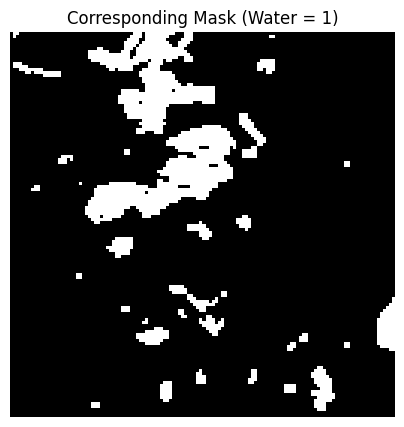

In [14]:
sample_idx = 0
sample_image = X[sample_idx]
sample_mask = y[sample_idx]

band_names = [
    "Coastal Aerosol", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
    "QA Band", "MERIT DEM", "Copernicus DEM", "ESA World Cover", "Water Occurrence"
]


fig, axes = plt.subplots(3, 4, figsize=(15, 10)) 
axes = axes.flatten()

for i in range(12):
    axes[i].imshow(sample_image[i], cmap='gray')
    axes[i].set_title(band_names[i])
    axes[i].axis('off')

plt.suptitle("Sample Image - All Bands", fontsize=16)
plt.tight_layout()
plt.show()

# Plot the corresponding mask
plt.figure(figsize=(5,5))
plt.imshow(sample_mask, cmap='gray')
plt.title("Corresponding Mask (Water = 1)")
plt.axis('off')
plt.show()

## Band Visualization Insights

From the band visualization, we can draw some important conclusions:

1) **Most Informative Bands for Water Detection**
   - Water Occurrence Probability
   - ESA World Cover Map
   - QA Band
   
2) **Strong Spectral Bands**
   - NIR
   - SWIR1
   - Green

3) **Moderate Bands**
   - SWIR2
   - Blue

4) **Less Useful for Water Segmentation**
   - Coastal Aerosol, Red, DEMs.

**Notes:**
- Visualization helps us understand **which bands provide the strongest water vs land contrast**.
- All bands will still be fed together to the model as input, but some bands are more influential.
- Masks should be compared visually to see how each band relates to the ground truth.

## Data preparation and split

In [15]:
#y.shape = (306, 128, 128) to (306, 1, 128, 128)
y_reshaped = y[:, np.newaxis, :, :]
print("Reshaped masks shape:", y_reshaped.shape)

y_binary = (y_reshaped > 0).astype(np.float32)
print("Unique values in masks after binarization:", np.unique(y_binary))

X_train, X_temp, y_train, y_temp = train_test_split(X, y_binary, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Test images:", X_test.shape)

Reshaped masks shape: (306, 1, 128, 128)
Unique values in masks after binarization: [0. 1.]
Train images: (214, 12, 128, 128)
Validation images: (46, 12, 128, 128)
Test images: (46, 12, 128, 128)


## Augmentation

In [16]:
X_aug_list = []
y_aug_list = []

for i in range(len(X_train)):
    img = torch.tensor(X_train[i], dtype=torch.float32)  #shape: (12, 128, 128)
    mask = torch.tensor(y_train[i], dtype=torch.float32) #shape: (1, 128, 128)

    if np.random.rand() > 0.5:
        img = TF.hflip(img)
        mask = TF.hflip(mask)

    if np.random.rand() > 0.5:
        img = TF.vflip(img)
        mask = TF.vflip(mask)

    angle = np.random.uniform(-20, 20)
    img = TF.rotate(img, angle)
    mask = TF.rotate(mask, angle)

    X_aug_list.append(img.numpy())
    y_aug_list.append(mask.numpy())

X_train_aug = np.array(X_aug_list)
y_train_aug = np.array(y_aug_list)

print("Augmented training images shape:", X_train_aug.shape)
print("Augmented training masks shape:", y_train_aug.shape)

Augmented training images shape: (214, 12, 128, 128)
Augmented training masks shape: (214, 1, 128, 128)


In [17]:
X_train_combined = np.concatenate([X_train, X_train_aug], axis=0)
y_train_combined = np.concatenate([y_train, y_train_aug], axis=0)

print("Combined training images shape:", X_train_combined.shape)
print("Combined training masks shape:", y_train_combined.shape)

Combined training images shape: (428, 12, 128, 128)
Combined training masks shape: (428, 1, 128, 128)


In [18]:
indices = np.arange(len(X_train_combined))
np.random.shuffle(indices)

X_train_combined = X_train_combined[indices]
y_train_combined = y_train_combined[indices]

print("Shuffling done!")

Shuffling done!


## Model

In [19]:
class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, features=[32, 64, 128]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        #encoder
        for feature in features:
            self.downs.append(self.conv_block(in_channels, feature))
            in_channels = feature

        #bottleneck
        self.bottleneck = self.conv_block(features[-1], features[-1]*2)

        #decoder
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(self.conv_block(feature*2, feature))

        #final 1x1 conv to get 1 channel output
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)



    def forward(self, x):
        skip_connections = []

        #encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        #bottleneck
        x = self.bottleneck(x)

        #decoder
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # upsample
            skip_connection = skip_connections[idx//2]
            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)
        return self.final_conv(x)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

### Tensors and dataloaders

In [20]:
train_dataset = TensorDataset(torch.tensor(X_train_combined, dtype=torch.float32),torch.tensor(y_train_combined, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),torch.tensor(y_val, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

### Device , model initialisation, loss fn and optimizer

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNet(in_channels=12, out_channels=1)
model = model.to(device)

#loss function
criterion = nn.BCEWithLogitsLoss()  #it combines sigmoid activation and binary cross entropy. Good for binary segmentation


#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  


Using device: cpu


## Training

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training", leave=False)
    for images, masks in train_loader_tqdm:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds == masks).sum().item()
        train_total += torch.numel(masks)

        batch_acc = (preds == masks).float().mean().item()
        train_loader_tqdm.set_postfix({'batch_loss': loss.item(), 'batch_acc': batch_acc})

    train_loss /= len(train_loader.dataset)
    train_acc = train_correct / train_total

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_loader_tqdm = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation", leave=False)
    with torch.no_grad():
        for images, masks in val_loader_tqdm:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == masks).sum().item()
            val_total += torch.numel(masks)

            batch_acc = (preds == masks).float().mean().item()
            val_loader_tqdm.set_postfix({'batch_loss': loss.item(), 'batch_acc': batch_acc})

    val_loss /= len(val_loader.dataset)
    val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}] -> "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

In [ ]:
torch.save(model.state_dict(), "unet_water_segmentation.pth")
print("Model saved!")

In [ ]:
model = UNet(in_channels=12, out_channels=1)

model.load_state_dict(torch.load("C:\\Users\\walaa\\Desktop\\Cellula CV\\Water Segmentation\\model\\water_unet5.pth",map_location=torch.device('cpu')))

model.to(device)
model.eval()

UNet(
  (downs): ModuleList(
    (0): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (ups): ModuleList(
    (0): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
    (1): Sequential(
      (0): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(12

In [ ]:
model.eval()
test_loss = 0
test_correct = 0
test_total = 0

test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.float32)),
                         batch_size=8, shuffle=False)

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)
        test_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) > 0.5).float()
        test_correct += (preds == masks).sum().item()
        test_total += torch.numel(masks)

test_loss /= len(test_loader.dataset)
test_acc = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Testing: 100%|██████████| 6/6 [00:02<00:00,  2.45it/s]

Test Loss: 0.1745, Test Accuracy: 0.9453


## Final Model Performance

After training and evaluation, the UNet model achieved the following results:

### Training Performance:

Final Training Loss: 0.1163
Final Training Accuracy: 95.07%

### Validation Performance:

Final Validation Loss: 0.1519
Final Validation Accuracy: 94.21%

### Test Performance:

Test Loss: 0.1745
Test Accuracy: 94.53%